In [1]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import json
import re

from node2vec import Node2Vec

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader,TensorDataset, Subset

from random import randint



DEBUG = True
RAW_DATA_PATH = 'Sim_Raw_data.parquet'
GRAPH_DATA_PATH = 'Sim_Graph.json'
SAVE_PATH_3 = "TRAINED/GMAN_model_reconstruct.pth"

SAMPLING = '1h'
MONTHS_HISTORY = 8

# CREATION GRAPH

In [2]:
with open(GRAPH_DATA_PATH, 'r') as f:
    G_router_json = json.load(f)

G_router = nx.node_link_graph(G_router_json)


NODE_LIST = list(G_router.nodes())
EDGE_LIST = list(G_router.edges())
NUM_NODES = len(NODE_LIST)
NUM_EDGES = len(EDGE_LIST)

print("NUmber of nodes: ", NUM_NODES)
print("NUmber of edges: ", NUM_EDGES)
print(f"NODE_LIST: {NODE_LIST} ")
print(f"EDGE_LIST: {EDGE_LIST}")

NUmber of nodes:  16
NUmber of edges:  16
NODE_LIST: ['HR_A', 'MR_A', 'HR_B', 'MR_B', 'C', 'D', 'A', 'B', 'E', 'S7', 'S6', 'S5', 'S3', 'S1', 'S2', 'S4'] 
EDGE_LIST: [('HR_A', 'MR_A'), ('MR_A', 'C'), ('HR_B', 'MR_B'), ('MR_B', 'MR_A'), ('MR_B', 'A'), ('C', 'D'), ('C', 'S7'), ('D', 'E'), ('D', 'S6'), ('D', 'S5'), ('A', 'B'), ('A', 'S1'), ('A', 'S2'), ('B', 'D'), ('B', 'S3'), ('E', 'S4')]


# DATA PREPARATION

In [3]:
DATA_RAW_MODEL = pd.read_parquet(RAW_DATA_PATH)
DATA_RAW_MODEL = DATA_RAW_MODEL.resample(SAMPLING).mean()

## 8 Months history
DATA_RAW_MODEL = DATA_RAW_MODEL[DATA_RAW_MODEL.index.month.isin(DATA_RAW_MODEL.index.month.unique()[-MONTHS_HISTORY:])]
DATA_RAW_MODEL = DATA_RAW_MODEL.round(2)
DATA_RAW_MODEL = DATA_RAW_MODEL[NODE_LIST]

display(DATA_RAW_MODEL)


,HR_A,MR_A,HR_B,MR_B,C,D,A,B,E,S7,S6,S5,S3,S1,S2,S4
2024-01-01 00:00:00,4.05,4.05,9.73,9.73,4.05,3.81,5.68,4.13,0.80,0.24,0.28,2.74,0.32,1.52,0.03,0.80
2024-01-01 01:00:00,3.13,3.13,9.49,9.49,3.13,3.13,6.36,3.29,0.80,0.00,0.28,2.05,0.16,3.04,0.03,0.80
2024-01-01 02:00:00,7.26,7.26,20.61,20.61,7.26,7.10,13.35,7.26,0.80,0.16,0.83,5.47,0.16,6.09,0.00,0.80
2024-01-01 03:00:00,18.44,18.44,50.27,50.27,18.44,17.97,31.83,18.13,4.01,0.47,0.28,13.68,0.16,13.70,0.00,4.01
2024-01-01 04:00:00,27.96,27.96,71.11,71.11,27.96,27.09,43.15,27.88,6.42,0.87,2.20,18.47,0.79,15.22,0.05,6.42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-28 19:00:00,861.22,861.22,2645.90,2645.90,861.22,809.22,1784.69,878.87,416.79,52.00,141.74,250.69,69.65,883.82,22.00,416.79
2024-06-28 20:00:00,544.12,544.12,1748.09,1748.09,544.12,503.77,1203.97,549.01,232.06,40.35,99.70,172.01,45.24,638.55,16.41,232.06
2024-06-28 21:00:00,229.89,229.89,758.65,758.65,229.89,208.01,528.76,227.51,116.79,21.88,44.80,46.42,19.49,291.70,9.55,116.79
2024-06-28 22:00:00,56.25,56.25,215.79,215.79,56.25,48.08,159.54,52.81,24.43,8.17,8.50,15.15,4.73,103.04,3.69,24.43


# GMAN MATRICES

## ADJACENCY MATRIX

In [4]:
def get_line_adjacency_matrix(G, NODE_LIST):
    """
    Returns the adjacency matrix of G_line as a numpy array, 
    preserving the order specified in NODE_LIST.
    """
    return nx.to_numpy_array(G, nodelist=NODE_LIST)

ADJ_MATRIX = get_line_adjacency_matrix(G_router, NODE_LIST)
ADJ_MATRIX_DF = pd.DataFrame(ADJ_MATRIX, columns=NODE_LIST, index=NODE_LIST).astype(int)
print("Adjacency Matrix:")
ADJ_MATRIX_DF

Adjacency Matrix:


,HR_A,MR_A,HR_B,MR_B,C,D,A,B,E,S7,S6,S5,S3,S1,S2,S4
HR_A,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
MR_A,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
HR_B,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
MR_B,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0
C,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0
D,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0
A,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0
B,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0
E,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
S7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## INCIDENCE MATRIX

In [5]:
def build_node_conservation_matrix(G, node_list):
    """
    Constructs a matrix where every row represents a Conservation Equation:
    Equation: Flow(Parent) - Sum(Flow(Children)) = 0
    
    Args:
        G (nx.DiGraph): The network topology.
        node_list (list): List of node names in the exact order of your data columns.
        
    Returns:
        np.ndarray: Matrix of shape [Num_Constraints, Num_Nodes]
        list: Labels for the rows (which Parent node each row represents)
    """
    node_to_idx = {n: i for i, n in enumerate(node_list)}
    num_nodes = len(node_list)
    
    constraints = []
    row_labels = [] 
    
    # Iterate over every node to see if it acts as a Parent (Source/Router)
    for parent in G.nodes():
        children = list(G.successors(parent))
        
        # If it has no children (Sink), there is no downstream flow to check
        if len(children) == 0:
            continue
            
        # Create a row of zeros
        row = np.zeros(num_nodes)
        
        # 1. The Parent (Source of flow) is Positive (+1)
        if parent in node_to_idx:
            row[node_to_idx[parent]] = 1.0
            
        # 2. The Children (Destination of flow) are Negative (-1)
        for child in children:
            if child in node_to_idx:
                row[node_to_idx[child]] = -1.0
                
        constraints.append(row)
        row_labels.append(parent)
        
    if not constraints:
        print("⚠️ Warning: No parent-child relationships found in Graph.")
        return np.zeros((0, num_nodes)), []

    # Stack into a single Matrix
    matrix = np.vstack(constraints)
    
    print(f"✅ Conservation Matrix Built: {matrix.shape}")
    print(f"   (Checking {matrix.shape[0]} Parent->Children groups)")
    
    return matrix, row_labels

INCIDENCE_MATRIX, row_labels = build_node_conservation_matrix(G_router, NODE_LIST)
INCIDENCE_MATRIX_DF = pd.DataFrame(INCIDENCE_MATRIX, columns=NODE_LIST, index=row_labels)
print("Incidence Matrix:")
display(INCIDENCE_MATRIX_DF)

if DEBUG:
    _flow_kirchoffs_test = []
    for _ in range(100):
        _test_flow = DATA_RAW_MODEL.sample(1)
        _flow = np.dot(INCIDENCE_MATRIX, _test_flow.T.values)
        _flow_kirchoffs_test.append(_flow.sum())
    
    print("The average loss is: {}".format(np.mean(_flow_kirchoffs_test)))

✅ Conservation Matrix Built: (9, 16)
   (Checking 9 Parent->Children groups)
Incidence Matrix:


,HR_A,MR_A,HR_B,MR_B,C,D,A,B,E,S7,S6,S5,S3,S1,S2,S4
HR_A,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
MR_A,0.0,1.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HR_B,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
MR_B,0.0,-1.0,0.0,1.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C,0.0,0.0,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0
D,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-1.0,0.0,-1.0,-1.0,0.0,0.0,0.0,0.0
A,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0
B,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,1.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0
E,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0


The average loss is: 0.0007000000000196194


## NODE MASKS

In [6]:
INNER_NODES_MASK =  (INCIDENCE_MATRIX_DF == 1).sum()
LEAF_NODES_MASK = (INNER_NODES_MASK == 0)*1

print(f"INNER_NODES_MASK: {INNER_NODES_MASK.values}")
print([x for i,x in enumerate(NODE_LIST) if INNER_NODES_MASK.iloc[i]])
print()
print(f"LEAF_NODES_MASK: {LEAF_NODES_MASK.values}")
print([x for i,x in enumerate(NODE_LIST) if LEAF_NODES_MASK.iloc[i]])

INNER_NODES_MASK: [1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0]
['HR_A', 'MR_A', 'HR_B', 'MR_B', 'C', 'D', 'A', 'B', 'E']

LEAF_NODES_MASK: [0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1]
['S7', 'S6', 'S5', 'S3', 'S1', 'S2', 'S4']


## MASK ATTENTION MASK

In [7]:
def generate_node_reconstruction_mask_numpy(G_physical, node_list, k_hops=1):
    """
    Generates a Node-to-Node Spatial Attention Mask as a NumPy array.
    
    Args:
        G_physical (nx.DiGraph): The router-to-router graph.
        node_list (list): The EXACT list of nodes in the desired order. 
        k_hops (int): Depth of vision (how far downstream to look).
        
    Returns:
        np.ndarray: Shape [N, N], dtype=bool.
                    True  = Blocked / Masked (Cannot attend).
                    False = Visible / Allowed (Can attend).
    """
    num_nodes = len(node_list)
    print(f"--- Generating Ordered Node Mask (NumPy) ---")
    
    # 1. Create Mapping
    # Ensures Row 0 is node_list[0], Row 1 is node_list[1]...
    node_to_idx = {node: i for i, node in enumerate(node_list)}
    
    # 2. Initialize Mask
    # Default is True (Blocked/Hidden)
    mask = np.ones((num_nodes, num_nodes), dtype=bool)
    
    # 3. Build Connectivity
    for i, u in enumerate(node_list):
        
        if u not in G_physical:
            print(f"⚠️ Warning: Node '{u}' not found in graph.")
            continue
            
        # A. Self-Attention (Always Allow)
            mask[i, i] = False

        
        # B. Downstream Lookup
        try:
            # Find all nodes 'v' reachable from 'u' within k_hops
            descendants = nx.single_source_shortest_path_length(G_physical, u, cutoff=k_hops)
            
            for v in descendants:
                if v in node_to_idx:
                    j = node_to_idx[v]
                    mask[i, j] = False # Make visible
            
            #if re.match(r'S\d+', u):
            #    mask[i, i] = False
            #else:
            #    mask[i, i] = True 
                    
        except Exception as e:
            print(f"Error processing node {u}: {e}")

   
    # Stats
    total_cells = num_nodes * num_nodes
    visible_cells = (~mask).sum() # Count False values
    print(f"✅ Mask Created. Shape ({num_nodes}, {num_nodes}). Visible Connections: {visible_cells}")
    
    return mask

NODE_LIST_IDX = {x:i for i,x in enumerate(NODE_LIST)}
ATT_MASK = generate_node_reconstruction_mask_numpy(G_router, NODE_LIST, k_hops=1)


for node_idx in ['HR_A', 'MR_A', 'HR_B', 'MR_B', 'C', 'D', 'A', 'B', 'E']:
    ATT_MASK[NODE_LIST_IDX[node_idx], NODE_LIST_IDX[node_idx]] = True

ATT_MASK_DF = pd.DataFrame(ATT_MASK, columns=NODE_LIST, index=NODE_LIST)*1
print("Reconstruction Attention Mask:")

ATT_MASK_T = torch.tensor(ATT_MASK).to(torch.bool)

ATT_MASK_DF

--- Generating Ordered Node Mask (NumPy) ---
✅ Mask Created. Shape (16, 16). Visible Connections: 32
Reconstruction Attention Mask:


,HR_A,MR_A,HR_B,MR_B,C,D,A,B,E,S7,S6,S5,S3,S1,S2,S4
HR_A,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1
MR_A,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1
HR_B,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1
MR_B,1,0,1,1,1,1,0,1,1,1,1,1,1,1,1,1
C,1,1,1,1,1,0,1,1,1,0,1,1,1,1,1,1
D,1,1,1,1,1,1,1,1,0,1,0,0,1,1,1,1
A,1,1,1,1,1,1,1,0,1,1,1,1,1,0,0,1
B,1,1,1,1,1,0,1,1,1,1,1,1,0,1,1,1
E,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0
S7,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1,1


# PARAMETERS

In [8]:
# TRAINING PARAMS
BATCH_SIZE = 32
EPOCHS = 30
LR = 0.001

# DATASET PARAMS
FREQ_H = int(re.search(r'[a-z]*(\d+)[a-z]*', SAMPLING)[1])
FREQ_MINUTES = FREQ_H*60
NUM_NODES = len(NODE_LIST)
HIST_STEPS = int(1*(24/FREQ_H))          # 1 day
PRED_STEPS = int(1*(24/FREQ_H))          # 1 day
INPUT_DIM = 1
OUTPUT_DIM = 1
D_MODEL = 32

STEPS_PER_DAY = int(24/FREQ_H)
DAYS_PER_WEEK = 7
MONTHS_PER_YEAR = 12


TIME_FEATURES = STEPS_PER_DAY + DAYS_PER_WEEK + MONTHS_PER_YEAR 

LAYERS_ENC_DEC = 3
K_HEADS = 4
D_HEADS = int(D_MODEL/K_HEADS)

print(f"Frequency: {FREQ_H} hours")
print(f"Frequency: {FREQ_MINUTES} minutes")
print(f"Number of nodes: {NUM_NODES}")
print(f"Number of historical steps: {HIST_STEPS}")
print(f"Number of prediction steps: {PRED_STEPS}")
print(f"Number of time features: {TIME_FEATURES}")
print(f"Input dimension: {INPUT_DIM}")
print(f"Output dimension: {OUTPUT_DIM}")
print(f"Model dimension: {D_MODEL}")
print(f"Steps per day: {STEPS_PER_DAY}")
print(f"Days per week: {DAYS_PER_WEEK}")
print(f"Months per year: {MONTHS_PER_YEAR}")
print(f"Layers encoder-decoder: {LAYERS_ENC_DEC}")
print(f"Number of heads: {K_HEADS}")
print(f"Dimension of each head: {D_HEADS}")

Frequency: 1 hours
Frequency: 60 minutes
Number of nodes: 16
Number of historical steps: 24
Number of prediction steps: 24
Number of time features: 43
Input dimension: 1
Output dimension: 1
Model dimension: 32
Steps per day: 24
Days per week: 7
Months per year: 12
Layers encoder-decoder: 3
Number of heads: 4
Dimension of each head: 8


# DATASETS / DATALOADERS

In [9]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data, num_his, num_pred):
        self.data = torch.FloatTensor(data)
        self.num_his = num_his
        self.num_pred = num_pred

    def __len__(self):
        return len(self.data) - self.num_his - self.num_pred + 1

    def __getitem__(self, idx):
        # Inputs: The historical window
        x = self.data[idx : idx + self.num_his]
        # Targets: The future window to predict
        y = self.data[idx + self.num_his : idx + self.num_his + self.num_pred]
        return x, y


if DEBUG:
    
    DATA_RAW_DS = TimeSeriesDataset(
        data=DATA_RAW_MODEL.values, 
        num_his=HIST_STEPS, 
        num_pred=PRED_STEPS)
        
    print(f"Dataset size: {len(DATA_RAW_DS)}")
    print(f"Data shape: {DATA_RAW_DS[0][0].shape}")
    print(f"Target shape: {DATA_RAW_DS[0][1].shape}")
    DATA_RAW_DL = DataLoader(DATA_RAW_DS, batch_size=BATCH_SIZE, shuffle=True)

    X, Y = next(iter(DATA_RAW_DL))
    print(f"X.shape: {X.shape}")
    print(f"Y.shape: {Y.shape}")


Dataset size: 4273
Data shape: torch.Size([24, 16])
Target shape: torch.Size([24, 16])
X.shape: torch.Size([32, 24, 16])
Y.shape: torch.Size([32, 24, 16])


In [10]:
from sklearn.preprocessing import StandardScaler

SCALER = StandardScaler()
DATA_RAW_MODEL_SCALED = SCALER.fit_transform(DATA_RAW_MODEL.values)

#DATA_RAW_MODEL_DS = TimeSeriesDataset(DATA_RAW_MODEL_SCALED, HIST_STEPS, PRED_STEPS)
total_samples = len(DATA_RAW_MODEL_SCALED)

print(f"Total valid sliding windows: {total_samples}")

train_size = int(total_samples * 0.8)
val_size = total_samples - train_size


train_data = DATA_RAW_MODEL_SCALED[:train_size]
val_data = DATA_RAW_MODEL_SCALED[train_size:]

TSS_TRAIN_DS = TimeSeriesDataset(train_data, HIST_STEPS, PRED_STEPS)
TSS_VAL_DS = TimeSeriesDataset(val_data, HIST_STEPS, PRED_STEPS)

print(f"Train size: {len(TSS_TRAIN_DS)}")
print(f"Val size: {len(TSS_VAL_DS)}")



TSS_TRAIN_DL = DataLoader(TSS_TRAIN_DS, batch_size=BATCH_SIZE, shuffle=True)
TSS_VAL_DL = DataLoader(TSS_VAL_DS, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(TSS_TRAIN_DL)} | Val samples: {len(TSS_VAL_DL)}")


if DEBUG:
    from random import randint

    _rand_idx = randint(0,len(TSS_TRAIN_DS))
    print()
    print(f"Random index: {_rand_idx}")
    X_real = DATA_RAW_MODEL.values[_rand_idx]
    print()
    print("X real:")
    print(X_real)

    _sample = TSS_TRAIN_DS[_rand_idx]

    X_scaled = _sample[0]
    Y_scaled = _sample[1]

    print()
    print('Data Scaled')
    print(X_scaled[0])


    X_un = (X_scaled * SCALER.scale_) + SCALER.mean_
    print()
    print("Data unscaled")
    print(X_un[0])

Total valid sliding windows: 4320
Train size: 3409
Val size: 817
Train samples: 107 | Val samples: 26

Random index: 2711

X real:
[14.04 14.04 41.36 41.36 14.04 13.56 27.32 14.81  3.82  0.48  2.52  7.22
  1.25 12.34  0.17  3.82]

Data Scaled
tensor([-0.9141, -0.9141, -0.9206, -0.9206, -0.9141, -0.9106, -0.9186, -0.9166,
        -0.8923, -0.9025, -0.8524, -0.8513, -0.8682, -0.8775, -0.8301, -0.8923])

Data unscaled
tensor([14.0400, 14.0400, 41.3600, 41.3600, 14.0400, 13.5600, 27.3200, 14.8100,
         3.8200,  0.4800,  2.5200,  7.2200,  1.2500, 12.3400,  0.1700,  3.8200],
       dtype=torch.float64)


# MODEL
## ITransformer

In [11]:
class iTransformer(nn.Module):
    """
    iTransformer: Inverted Transformer for Time Series Forecasting.
    
    Ref: iTransformer: Inverted Transformers are Effective for Time Series Forecasting
    """
    def __init__(self, num_variates, hist_steps, pred_steps, d_model=512, n_heads=8, num_layers=2, dropout=0.1, attn_mask=None):
        super(iTransformer, self).__init__()
        
        self.hist_steps = hist_steps
        self.pred_steps = pred_steps
        self.d_model = d_model

        # 1. Embedding: Project the entire lookback window (T) to feature dimension (D)
        # In iTransformer, the MLP acts on the time dimension.
        # Input: (Batch, Num_Variates, Lookback_Len) -> Output: (Batch, Num_Variates, d_model)
        self.embedding = nn.Linear(hist_steps, d_model)
        
        # 2. Transformer Encoder: Captures multivariate correlations
        # The sequence length here is 'Num_Variates', not time steps.
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=n_heads, 
            dim_feedforward=d_model * 4, 
            dropout=dropout, 
            batch_first=True,
            norm_first=False # Paper uses Post-LN generally, though Pre-LN is often more stable
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # 3. Projection: Project feature dimension (D) to prediction horizon (S)
        # Input: (Batch, Num_Variates, d_model) -> Output: (Batch, Num_Variates, Pred_Len)
        self.projection = nn.Linear(d_model, pred_steps)

        if attn_mask is not None:
            # We force it to float() right here to prevent TypeErrors later
            print(f"✔️ Att mask set")
            self.register_buffer('attn_mask', attn_mask.float())
        else:
            self.attn_mask = None

    def forward(self, x):
        # x shape: [Batch, hist_steps, Num_Variates]
        
        # Step 1: Invert dimensions to [Batch, Num_Variates, hist_steps]
        # This treats each variate as a "token" and the time series as the "embedding"
        x = x.permute(0, 2, 1) 
        
        # Step 2: Embedding (Linear Layer applied to the time dimension)
        # x shape becomes: [Batch, Num_Variates, d_model]
        x = self.embedding(x)
        
        # Step 3: Multivariate Interaction (Self-Attention)
        # Attention is calculated between variates.
        x = self.encoder(x, mask=self.attn_mask)
        
        # Step 4: Projection to forecast horizon
        # x shape becomes: [Batch, Num_Variates, pred_steps]
        x = self.projection(x)
        
        # Step 5: Invert back to [Batch, pred_steps, Num_Variates] to match ground truth
        x = x.permute(0, 2, 1)
        
        return x

if DEBUG:
    embedding = nn.Linear(HIST_STEPS, D_MODEL)

    encoder_layer = nn.TransformerEncoderLayer(
            d_model=D_MODEL, 
            nhead=K_HEADS, 
            dim_feedforward=D_MODEL * 4, 
            batch_first=True,
            norm_first=False # Paper uses Post-LN generally, though Pre-LN is often more stable
        )

    encoder = nn.TransformerEncoder(encoder_layer, num_layers=LAYERS_ENC_DEC)

    projection = nn.Linear(D_MODEL, PRED_STEPS)
 
    for X_d, Y_d in TSS_TRAIN_DL:
            if randint(0,10) == 4:
                break

    print(f"X_d shape: {X_d.shape}")
    print(f"Y_d shape: {Y_d.shape}")

    X_d = X_d.permute(0, 2, 1)
    print(f"X_d shape inverted: {X_d.shape}")

    X_d = embedding(X_d)
    print(f"X_d shape embedded: {X_d.shape}")

    X_d = encoder(X_d)
    print(f"X_d shape encoded: {X_d.shape}")

    X_d = projection(X_d)
    print(f"X_d shape projected: {X_d.shape}")

    X_d = X_d.permute(0, 2, 1)
    print(f"X_d shape inverted: {X_d.shape}")

X_d shape: torch.Size([32, 24, 16])
Y_d shape: torch.Size([32, 24, 16])
X_d shape inverted: torch.Size([32, 16, 24])
X_d shape embedded: torch.Size([32, 16, 32])
X_d shape encoded: torch.Size([32, 16, 32])
X_d shape projected: torch.Size([32, 16, 24])
X_d shape inverted: torch.Size([32, 24, 16])


# TRAINNIG

In [12]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Training on: {DEVICE}")

Training on: cuda


In [13]:
PATIENCE = 5

class EarlyStopping:
    def __init__(self, patience=5, verbose=True, delta=0, path='best_model.pth'):
        """
        Args:
            patience (int): How many epochs to wait after last time val_loss improved.
            verbose (bool): If True, prints a message for each validation loss improvement.
            delta (float): Minimum change in the monitored quantity to qualify as an improvement.
            path (str): Path for the checkpoint to be saved to.
        """
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.Inf
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        '''Saves model when validation loss decreases.'''
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss
        
def train_model(model, device, train_loader, val_loader, optimizer, loss_fn, early_stopping, checkpoint_path, epochs):

    print("Starting Training...")

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                
            optimizer.zero_grad()
                
            # Forward pass
            outputs = model(batch_x)
                
            # Loss calculation
            loss = loss_fn(outputs, batch_y)
            loss.backward()
            optimizer.step()
                
            train_loss += loss.item()
            
        avg_train_loss = train_loss / len(train_loader)
            
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                loss = loss_fn(outputs, batch_y)
                val_loss += loss.item()
    
        avg_val_loss = val_loss / len(val_loader)
        
        print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.5f}, Val Loss: {avg_val_loss:.5f}")


        # Early Stopping
        early_stopping(avg_val_loss, model)
        if early_stopping.early_stop:
            print("Early stopping triggered. Training stopped.")
            break

    # Load best model
    model.load_state_dict(torch.load(checkpoint_path))
    print("Best model weights loaded for testing.")

    return model

### TRAINING PROCESS

In [14]:
   
DIR_TRAINED = "TRAINED_MODELS"

## MODEL ZERO  (MSE ONLY)

In [15]:
MODEL = iTransformer(
        num_variates=NUM_NODES,
        hist_steps=HIST_STEPS,
        pred_steps=PRED_STEPS,
        d_model=D_MODEL,   
        num_layers=LAYERS_ENC_DEC,  
        n_heads=K_HEADS
).to(DEVICE)



PREFIX_MODEL = 'itransformer_model_zero'
CHECKPOINT_PATH = f'{DIR_TRAINED}/best_{PREFIX_MODEL}.pth'
print(f"Checkpoint path: {CHECKPOINT_PATH}")



early_stopping = EarlyStopping(patience=PATIENCE, verbose=True, path=CHECKPOINT_PATH)
optimizer = torch.optim.Adam(MODEL.parameters(), lr=LR)

loss_fn = nn.MSELoss()

Checkpoint path: TRAINED_MODELS/best_itransformer_model_zero.pth


In [16]:
MODEL = train_model(
    MODEL,
    DEVICE,
    TSS_TRAIN_DL,
    TSS_VAL_DL,
    optimizer,
    loss_fn,
    early_stopping,
    CHECKPOINT_PATH,
    EPOCHS
)


OUTPUT_MODEL = f'{DIR_TRAINED}/{PREFIX_MODEL}_trained.pth'
torch.save(MODEL.state_dict(), OUTPUT_MODEL)
print(f"Model saved to {OUTPUT_MODEL}")

Starting Training...
Epoch [1/30], Train Loss: 0.25033, Val Loss: 0.12891
Validation loss decreased (inf --> 0.128908).  Saving model ...
Epoch [2/30], Train Loss: 0.12102, Val Loss: 0.12086
Validation loss decreased (0.128908 --> 0.120857).  Saving model ...
Epoch [3/30], Train Loss: 0.11124, Val Loss: 0.11307
Validation loss decreased (0.120857 --> 0.113069).  Saving model ...
Epoch [4/30], Train Loss: 0.10584, Val Loss: 0.11057
Validation loss decreased (0.113069 --> 0.110571).  Saving model ...
Epoch [5/30], Train Loss: 0.10291, Val Loss: 0.10933
Validation loss decreased (0.110571 --> 0.109333).  Saving model ...
Epoch [6/30], Train Loss: 0.09987, Val Loss: 0.10521
Validation loss decreased (0.109333 --> 0.105211).  Saving model ...
Epoch [7/30], Train Loss: 0.09665, Val Loss: 0.10380
Validation loss decreased (0.105211 --> 0.103798).  Saving model ...
Epoch [8/30], Train Loss: 0.09576, Val Loss: 0.10412
EarlyStopping counter: 1 out of 5
Epoch [9/30], Train Loss: 0.09477, Val Loss

## MODEL WITH ATTENTION MASK

In [ ]:



MODEL = iTransformer(
        num_variates=NUM_NODES,
        hist_steps=HIST_STEPS,
        pred_steps=PRED_STEPS,
        d_model=D_MODEL,   
        num_layers=LAYERS_ENC_DEC,  
        n_heads=K_HEADS,
        attn_mask=ATT_MASK_T
).to(DEVICE)



PREFIX_MODEL = 'itransformer_model_att_mask'
CHECKPOINT_PATH = f'{DIR_TRAINED}/best_{PREFIX_MODEL}.pth'
print(f"Checkpoint path: {CHECKPOINT_PATH}")

early_stopping = EarlyStopping(patience=PATIENCE, verbose=True, path=CHECKPOINT_PATH)
optimizer = torch.optim.Adam(MODEL.parameters(), lr=LR)

loss_fn = nn.MSELoss()

✔️ Att mask set
Checkpoint path: TRAINED_MODELS/best_itransformer_model_att_mask.pth


In [21]:
MODEL = train_model(
    MODEL,
    DEVICE,
    TSS_TRAIN_DL,
    TSS_VAL_DL,
    optimizer,
    loss_fn,
    early_stopping,
    CHECKPOINT_PATH,
    EPOCHS
)

OUTPUT_MODEL = f'{DIR_TRAINED}/{PREFIX_MODEL}_trained.pth'
torch.save(MODEL.state_dict(), OUTPUT_MODEL)
print(f"Model saved to {OUTPUT_MODEL}")

Starting Training...
Epoch [1/30], Train Loss: 0.26161, Val Loss: 0.16015
Validation loss decreased (inf --> 0.160150).  Saving model ...
Epoch [2/30], Train Loss: 0.12422, Val Loss: 0.14933
Validation loss decreased (0.160150 --> 0.149332).  Saving model ...
Epoch [3/30], Train Loss: 0.11320, Val Loss: 0.14605
Validation loss decreased (0.149332 --> 0.146048).  Saving model ...
Epoch [4/30], Train Loss: 0.10576, Val Loss: 0.13650
Validation loss decreased (0.146048 --> 0.136501).  Saving model ...
Epoch [5/30], Train Loss: 0.10289, Val Loss: 0.14141
EarlyStopping counter: 1 out of 5
Epoch [6/30], Train Loss: 0.09801, Val Loss: 0.13438
Validation loss decreased (0.136501 --> 0.134385).  Saving model ...
Epoch [7/30], Train Loss: 0.09583, Val Loss: 0.13556
EarlyStopping counter: 1 out of 5
Epoch [8/30], Train Loss: 0.09506, Val Loss: 0.13262
Validation loss decreased (0.134385 --> 0.132625).  Saving model ...
Epoch [9/30], Train Loss: 0.09344, Val Loss: 0.12953
Validation loss decreased

## MODEL WITH PHYSCIS

In [22]:
      
def train_model_physics(model, device, train_loader, val_loader, optimizer, loss_fn, early_stopping, checkpoint_path, epochs=30):

    print("Starting Training...")


    for epoch in range(epochs):
        print(f"Epoch [{epoch+1}/{epochs}]")
        # Train
        model.train()
        total_loss = 0
        total_mse_loss = 0
        total_phy_loss = 0

        for batch_idx, (X, Y) in enumerate(train_loader):
            X, Y = X.to(device), Y.to(device)

            optimizer.zero_grad()
            preds = model(X)
            
            loss, mse_val, phy_val = loss_fn(preds, Y)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            total_mse_loss += mse_val
            total_phy_loss += phy_val
            
        avg_train_loss = total_loss / len(train_loader)
        avg_mse_loss = total_mse_loss / len(train_loader)
        avg_phy_loss = total_phy_loss / len(train_loader)

        print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {avg_train_loss:.4f}, MSE Loss: {avg_mse_loss:.4f}, Physics Loss: {avg_phy_loss:.4f}")

        # Validation
        model.eval()
        val_loss = 0
        val_mse_loss = 0
        val_phy_loss = 0
        with torch.no_grad():
            for batch_idx, (X, Y) in enumerate(val_loader):
                X, Y = X.to(device), Y.to(device)

                preds = model(X)
                loss, mse_val, phy_val = loss_fn(preds, Y)
                val_loss += loss.item()
                val_mse_loss += mse_val
                val_phy_loss += phy_val
                
        avg_val_loss = val_loss / len(val_loader)
        avg_val_mse_loss = val_mse_loss / len(val_loader)
        avg_val_phy_loss = val_phy_loss / len(val_loader)

        print(f"Epoch [{epoch+1}/{epochs}] - Validation Loss: {avg_val_loss:.4f}, MSE Loss: {avg_val_mse_loss:.4f}, Physics Loss: {avg_val_phy_loss:.4f}")
        
        # Early Stopping
        
        if early_stopping is not None:
            early_stopping(avg_val_loss, model)
            if early_stopping.early_stop:
                print("Early stopping triggered. Training stopped.")
                break

    # Load best model
    model.load_state_dict(torch.load(checkpoint_path))
    print("Best model weights loaded for testing.")

    return model

In [42]:
class BottomUpReconstructionLoss(nn.Module):
    def __init__(self, G_physical, device='cpu'):
        super(BottomUpReconstructionLoss, self).__init__()
        
        # Adjacency: Rows=Parents, Cols=Children
        adj = nx.to_numpy_array(G_physical)
        self.adj_matrix = torch.tensor(adj, dtype=torch.float32).to(device)
        
        # Identify Parents (Nodes with outgoing edges/children)
        row_sum = self.adj_matrix.sum(dim=1)
        self.parent_mask = (row_sum > 0).float().view(1, 1, -1).to(device)

    def forward(self, Y_pred_real, Y_true_real, mask_physics):
        # 1. Mix flows: Use Ground Truth for Leaves (Mask=1), Preds for Parents (Mask=0)
        # This propagates the "True" leaf traffic up to the parents

        #F_children = mask_physics * Y_true_real + (1 - mask_physics) * Y_pred_real
        F_children = Y_pred_real
        # 2. Reshape for Matrix Mult: [Batch*Time, Nodes]


        B, T, C = F_children.shape
        F_flat = F_children.reshape(B*T,C)
        
        # 3. Sum Children to find Expected Parent Flow
        # Parent_i = Sum(A_ij * Child_j) -> MatMul(F, A.T)
        F_reconstructed_flat = torch.matmul(F_flat, self.adj_matrix.t())
        F_reference = F_reconstructed_flat.reshape(B, T, C)
        
        # 4. Compare: Does Model's Parent Prediction == Sum of Children?
        # Note: We compare against Y_pred_real (what the model thinks the parent is)
        diff = Y_pred_real - F_reference
        
        # 5. Mask: Only punish Parent nodes (leaves don't have children to sum)
        loss = (diff ** 2) * self.parent_mask
        
        return loss.mean()

class CombinedTrafficLoss(nn.Module):
    def __init__(self, G_physical, scaler, leaf_mask, device='cpu', lambda_phy=0.1):
        """
        Args:
            G_physical: NetworkX graph (Parent -> Child edges).
            scaler: The Scaler used to scale the data.
            leaf_mask: Mask for leaf nodes.
            device: 'cuda' or 'cpu'.
            lambda_phy: Weighting factor for the physics loss (default 0.1).
        """
        super(CombinedTrafficLoss, self).__init__()
        self.lambda_phy = lambda_phy
        self.device = device
        
        # 1. Standard Data Loss (MSE)
        self.mse = nn.MSELoss()
        
        # 2. Physics Loss (Bottom-Up Reconstruction)
        self.bottom_up = BottomUpReconstructionLoss(G_physical, device)
        
        # 3. Stats for Differentiable Reverse Transform
        # We need these to convert Z-scores to Real Flow inside the loss
       
        self.means = torch.as_tensor(scaler.mean_, device=device).float()
        self.scale = torch.as_tensor(scaler.scale_, device=device).float()

     

        self.leaf_mask = leaf_mask.detach().clone().to(dtype=torch.float32, device=device).view(1, 1, -1)

    def forward(self, Y_pred, Y_true):
        """
        Args:
            Y_pred: Model output (Normalized Z-Scores)
            Y_true: Ground Truth (Normalized Z-Scores)
        """
        B,T,C = Y_true.shape

        # --- 1. Data Loss (MSE) ---
        # Calculated on Normalized data (Standard Deep Learning practice)
        loss_data = self.mse(Y_pred, Y_true)
        
        # --- 2. Physics Preparation (Reverse Transform) ---
        # We must un-scale the data to check Flow Conservation.
        # Since this is just (X * std) + mean, it preserves Gradients!
        Y_pred_real = (Y_pred * self.scale) + self.means
        Y_true_real = (Y_true * self.scale) + self.means
        
        # --- 3. Physics Loss (Bottom-Up) ---
        # Calculated on Real Units
        loss_physics = self.bottom_up(Y_pred_real, Y_true_real, self.leaf_mask)
        
        # --- 4. Combine ---
        total_loss = loss_data + (self.lambda_phy * loss_physics)
        
        return total_loss, loss_data, loss_physics


if False:
    import random

    model = iTransformer(
        num_variates=NUM_NODES,
        hist_steps=HIST_STEPS,
        pred_steps=PRED_STEPS,
        d_model=D_MODEL,   
        num_layers=LAYERS_ENC_DEC,  
        n_heads=K_HEADS,
        attn_mask=ATT_MASK_T
    )

    PREFIX_MODEL = 'itransformer_model_att_mask'
    print(f"Retrieving model from {PREFIX_MODEL}_trained.pth")
    state_dict = torch.load(f'{PREFIX_MODEL}_trained.pth')
    model.load_state_dict(state_dict)

    model.eval()

   
    for batch_idx, (X_scaled,Y_scaled) in enumerate(TSS_VAL_DL):
        if random.randint(0,10) == 5:
            break
   
    B,T,C = X_scaled.shape
    print(f"X_scaled shape: {X_scaled.shape}")
    print(f"Y_scaled shape: {Y_scaled.shape}")
    
    with torch.no_grad():
        Y_pred_scaled = model(X_scaled)

    means = torch.as_tensor(SCALER.mean_, device=Y_pred_scaled.device, dtype=Y_pred_scaled.dtype)
    stds = torch.as_tensor(SCALER.scale_, device=Y_pred_scaled.device, dtype=Y_pred_scaled.dtype)


    Y_true_real = (Y_scaled * stds) + means
    Y_pred_real = (Y_pred_scaled * stds) + means

    
    print(f"Y_true_real shape: {Y_true_real.shape}")
    print(f"Y_pred_real shape: {Y_pred_real.shape}")


    print()
    ############# LOSS FUNCTION ##########
    adj = nx.to_numpy_array(G_router)
    adj_matrix = torch.tensor(adj, dtype=torch.float32)
    mask_physics = torch.tensor(LEAF_NODES_MASK.values).clone().view(1, 1, -1)
    print(f"mask_physics: {mask_physics}")
    print(f"mask_physics shape: {mask_physics.shape}")

    row_sum = adj_matrix.sum(dim=1)
    parent_mask = (row_sum > 0).float().view(1, 1, -1)
    print(f"parent_mask: {parent_mask}")
    print(f"parent_mask shape: {parent_mask.shape}")
    print()
    print(f"🌲 Bottom-Up Loss Initialized.")
    print(f"   Parents (Targets): {int(parent_mask.sum().item())}")
    print(f"   Children (Sources): {len(G_router.nodes) - int(parent_mask.sum().item())}")
    print()

    

    F_children = mask_physics * Y_true_real + (1 - mask_physics) * Y_pred_real
    F_children = Y_pred_real

    print(f"F_children shape: {F_children.shape}")

    B, T, C = F_children.shape
    F_flat = F_children.reshape(B*T,C)
    print(f"F_flat shape: {F_flat.shape}")

    F_reconstructed_parents = torch.matmul(F_flat, adj_matrix.T)
    print(f"F_reconstructed_parents shape: {F_reconstructed_parents.shape}")
    F_reference = F_reconstructed_parents.view(B, T, C)
    print(f"F_reference shape: {F_reference.shape}")

    diff = (Y_pred_real - F_reference)*parent_mask
    print(f"diff shape: {diff.shape}")

    loss = (diff ** 2) * parent_mask
    print(f"the error mean is : {loss.mean()}")


if False:
    ############### TEST REAL

    _pred_ds =  TimeSeriesDataset(
        data=DATA_RAW_MODEL_SCALED, 
        num_his=HIST_STEPS, 
        num_pred=PRED_STEPS
        )

    _pred_dl = DataLoader(_pred_ds, batch_size=32, shuffle=False)
    for X_l,Y_l in _pred_dl:
        pass
    
    print(f"X_l shape: {X_l.shape}")
    print(f"Y_l shape: {Y_l.shape}")
    X_l_real = (X_l * stds) + means
    Y_l_real = (Y_l * stds) + means
    print(f"X_l_real: {X_l_real.shape}")
    print(f"Y_l_real: {Y_l_real.shape}")

    _test_plot = pd.DataFrame(X_l_real[0].numpy(), columns=NODE_LIST)[['E','S4']]

    _loss_fn = BottomUpReconstructionLoss(G_router)
    _leaf_nodes_mask = torch.tensor(LEAF_NODES_MASK.values).clone().view(1, 1, 1, -1)

    X_l_real_un = X_l_real[0].reshape(1,24,-1)

    res = _loss_fn(X_l_real_un,X_l_real_un,mask_physics=_leaf_nodes_mask)

    print(res)


    
    

In [25]:
MODEL = iTransformer(
        num_variates=NUM_NODES,
        hist_steps=HIST_STEPS,
        pred_steps=PRED_STEPS,
        d_model=D_MODEL,   
        num_layers=LAYERS_ENC_DEC,  
        n_heads=K_HEADS,
        attn_mask=ATT_MASK_T
).to(DEVICE)

LEAF_NODES_MASK_T = torch.tensor(LEAF_NODES_MASK.values).clone().view(1, 1, 1, -1).to(DEVICE)

PATIENCE = 10
PREFIX_MODEL = 'model_itransformer_att_phy_mask'
CHECKPOINT_PATH = f'{DIR_TRAINED}/best_{PREFIX_MODEL}.pth'
print(f"Checkpoint path: {CHECKPOINT_PATH}")


early_stopping = EarlyStopping(patience=PATIENCE, verbose=True, path=CHECKPOINT_PATH)
optimizer = torch.optim.Adam(MODEL.parameters(), lr=LR)

loss_fn = CombinedTrafficLoss(
        G_physical=G_router, 
        scaler=SCALER, 
        leaf_mask=LEAF_NODES_MASK_T,
        device=DEVICE, 
        lambda_phy=100
).to(DEVICE)

✔️ Att mask set
Checkpoint path: TRAINED_MODELS/best_model_itransformer_att_phy_mask.pth


In [26]:
MODEL = train_model_physics(
    MODEL,
    DEVICE,
    TSS_TRAIN_DL,
    TSS_VAL_DL,
    optimizer,
    loss_fn,
    early_stopping,
    CHECKPOINT_PATH,
    EPOCHS
)

OUTPUT_MODEL = f'{DIR_TRAINED}/{PREFIX_MODEL}_trained.pth'
torch.save(MODEL.state_dict(), OUTPUT_MODEL)
print(f"Model saved to {OUTPUT_MODEL}")

Starting Training...
Epoch [1/30]
Epoch [1/30] - Train Loss: 541745.2345, MSE Loss: 0.3251, Physics Loss: 5417.4482
Epoch [1/30] - Validation Loss: 259944.6472, MSE Loss: 0.1802, Physics Loss: 2599.4448
Validation loss decreased (inf --> 259944.647236).  Saving model ...
Epoch [2/30]
Epoch [2/30] - Train Loss: 217714.6184, MSE Loss: 0.1413, Physics Loss: 2177.1443
Epoch [2/30] - Validation Loss: 239642.2449, MSE Loss: 0.1610, Physics Loss: 2396.4204
Validation loss decreased (259944.647236 --> 239642.244892).  Saving model ...
Epoch [3/30]
Epoch [3/30] - Train Loss: 181077.8764, MSE Loss: 0.1284, Physics Loss: 1810.7771
Epoch [3/30] - Validation Loss: 232995.4853, MSE Loss: 0.1547, Physics Loss: 2329.9536
Validation loss decreased (239642.244892 --> 232995.485276).  Saving model ...
Epoch [4/30]
Epoch [4/30] - Train Loss: 166608.6460, MSE Loss: 0.1214, Physics Loss: 1666.0852
Epoch [4/30] - Validation Loss: 227931.4309, MSE Loss: 0.1495, Physics Loss: 2279.3127
Validation loss decrease

# VALIDATION MODELS

In [32]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import seaborn as sns
import random

def validate_plots(model, dataloader, scaler, device, num_nodes_to_plot=3):
    """
    Takes a random batch from the dataloader, predicts, and plots the results.
    
    Args:
        model: Trained GMAN model.
        dataloader: Validation/Test DataLoader (Shuffle=True recommended for randomness).
        device: 'cuda' or 'cpu'.
        node_mode: Optional mask for heterogeneous nodes.
        num_nodes_to_plot: How many random nodes to visualize from the sample.
    """
    model.eval()
    
    # 1. Get a single batch
    # We use next(iter()) which grabs the first batch. 
    # If your loader has shuffle=True, this is random.
  
    X, Y_true_scaled = next(iter(dataloader))


    # Move to Device
    X = X.to(device)
    B,T,C = X.shape
    
    # 2. Inference
    with torch.no_grad():
        Y_pred_scaled = model(X)

    # 3. Inverse Transform (Get Real Units)
    # The dataset handles the math to get back to Gbps/Mbps
    Y_true_real = scaler.inverse_transform(Y_true_scaled.reshape(B*T,C)).reshape(B,T,C)
    Y_pred_real = scaler.inverse_transform(Y_pred_scaled.reshape(B*T,C)).reshape(B,T,C) 


    # 4. Select a Random Sample from the Batch
    batch_size = Y_true_real.shape[0]
    sample_idx = random.randint(0, batch_size - 1)
    
    # 5. Select Random Nodes to Plot
    num_nodes = Y_true_real.shape[2]
    # Ensure we don't try to plot more nodes than exist
    nodes_to_plot = random.sample(range(num_nodes), min(num_nodes, num_nodes_to_plot))
    
    # 6. Plotting
    fig, axes = plt.subplots(len(nodes_to_plot), 1, figsize=(10, 4 * len(nodes_to_plot)), sharex=True)
    if len(nodes_to_plot) == 1: axes = [axes] # Handle single plot case
    
    time_steps = np.arange(Y_true_real.shape[1]) # 0 to Q-1
    
    print(f"📊 Visualization for Batch Sample #{sample_idx}")
    
    for i, node_idx in enumerate(nodes_to_plot):
        ax = axes[i]
        
        # Extract data for this specific node and sample
        truth = Y_true_real[sample_idx, :, node_idx]
        pred = Y_pred_real[sample_idx, :, node_idx]
        
        # Plot
        ax.plot(time_steps, truth, label='Ground Truth', color='blue', linewidth=2, marker='o', markersize=4)
        ax.plot(time_steps, pred, label='Prediction', color='red', linestyle='--', linewidth=2, marker='x', markersize=4)
        
        # Formatting
        ax.set_title(f"Node Index: {node_idx}", fontsize=12, fontweight='bold')
        ax.set_ylabel("Traffic (Real Units)")
        ax.grid(True, linestyle=':', alpha=0.6)
        if i == 0:
            ax.legend()

    plt.xlabel("Prediction Time Steps (Future)")
    plt.tight_layout()
    plt.show()

def validate_model(model, dataloader, scaler, device):
    """
    Evaluates the model on the validation set using Real-World Units.
    
    Args:
        model: The trained GMAN model.
        dataloader: DataLoader containing the validation set.
        device: 'cuda' or 'cpu'.
        node_mode: (Optional) The mask for heterogeneous attention we discussed.
        
    Returns:
        metrics: Dictionary containing MAE, RMSE, and MAPE in real units.
    """
    model.eval()  # Set model to evaluation mode (disables dropout, etc.)
    
    total_mae = []
    total_rmse = []
    total_mape = []
    
    # Disable gradient calculation for efficiency
    with torch.no_grad():
        for batch_idx, (X, Y_true_scaled) in enumerate(dataloader):
            
            # 1. Move data to GPU
            X = X.to(device)
            B,T,C = X.shape
           
            # Y_true_scaled is the Normalized Target (Z-Score)
            
            Y_pred_scaled = model(X)
            
            # 3. INVERSE TRANSFORM (The Key Step)
            # Convert Z-Scores back to Real Traffic (e.g., Gbps)
            # We use the dataset attached to the loader
            Y_pred_real = scaler.inverse_transform(Y_pred_scaled.reshape(B*T,C)).reshape(B,T,C)
            Y_true_real = scaler.inverse_transform(Y_true_scaled.reshape(B*T,C)).reshape(B,T,C)
            

           
            
            # MAE (Mean Absolute Error)
            batch_mae = mean_absolute_error(Y_true_real.flatten(), Y_pred_real.flatten())
            total_mae.append(batch_mae)
            
            # RMSE (Root Mean Squared Error)
            batch_mse = mean_squared_error(Y_true_real.flatten(), Y_pred_real.flatten())
            total_rmse.append(np.sqrt(batch_mse))
            
            # MAPE (Mean Absolute Percentage Error)
            # We must mask out zeros/very small values to avoid division by zero/infinity
            mask = Y_true_real > 0.1 # Adjust 0.1 to your data's noise floor
            if np.sum(mask) > 0:
                batch_mape = np.mean(np.abs((Y_true_real[mask] - Y_pred_real[mask]) / Y_true_real[mask]))
                total_mape.append(batch_mape)
    
    # 5. Aggregate Results
    metrics = {
        'MAE': np.mean(total_mae),
        'RMSE': np.mean(total_rmse),
        'MAPE': np.mean(total_mape) * 100 # Convert to Percentage
    }
    
    print(f"Validation Complete.")
    print(f"MAE:  {metrics['MAE']:.4f} (Real Units)")
    print(f"RMSE: {metrics['RMSE']:.4f} (Real Units)")
    print(f"MAPE: {metrics['MAPE']:.2f}%")
    
    return metrics

def prediction(model, data:pd.DataFrame, hist_steps, pred_steps, scaler, device='cpu'):

    model.eval()
    model.to(device)

    
    _dates_pred = pd.date_range(start=data.index[-1] + pd.Timedelta(hours=1), periods=pred_steps, freq='h')
    
    _pred_ds =  TimeSeriesDataset(
        data=data.values, 
        num_his=hist_steps, 
        num_pred=pred_steps
        )

    _pred_dl = DataLoader(_pred_ds, batch_size=1, shuffle=False)
    for X,Y in _pred_dl:
        break
    
    B,T,C = X.shape


    with torch.no_grad():
        _pred_scaled = model(X)

    _pred = scaler.inverse_transform(_pred_scaled.reshape(B*T,C)).reshape(B,T,C)
    _pred_df = pd.DataFrame(_pred[-1], index=_dates_pred, columns=data.columns)

    return _pred_df

def plot_prediction(model, data_raw, hist_steps, pred_steps, steps_to_predict, scaler, device='cpu', node_selected=None):

    data_new = data_raw.copy()
    last_date = data_raw.index[-1]
    print(f"The last date is {last_date}")



    for _ in range(steps_to_predict):
        data_new = pd.concat([
            data_new, 
            prediction(model, data_new, hist_steps, pred_steps, scaler, device)
            ], axis=0)

    data_new = data_new[data_new.index > last_date]

    ### PLOTIING ################################
    # Select a random channel
    if node_selected is None:
        random_channel = np.random.randint(0, data_raw.shape[1])
    else:

        random_channel = [i for i,x in enumerate(data_raw.columns) if x == node_selected ][0]
        print(f'Node Selected: {node_selected} -> {random_channel}')

    last_month_points = 150

    plt.figure(figsize=(15, 5))
    plt.plot(data_raw.iloc[-last_month_points:, random_channel], label='Raw Data (Last Month)', alpha=0.7)
    plt.plot(data_new.iloc[:, random_channel], label='New Data', alpha=0.9)
    plt.title(f'Comparison for Node {data_raw.columns[random_channel]}')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

    return data_new

def analyze_attention_preference(model, dataloader, node_list, layer_index=0, device='cuda'):
    """
    layer_index: Which STAttBlock to inspect (0 = first layer, -1 = last layer)
    """
    model.eval()
    
    # Get one batch
    X, TE, _ = next(iter(dataloader))
    X, TE = X.to(device), TE.to(device)
    
    # Run Forward Pass
    with torch.no_grad():
        _ = model(X, TE)
    
    # Extract z from the specific encoder layer
    # Access: model -> encoder_layers -> [i] -> gated_fusion -> last_gate_values
    # Shape of z: [Batch, Time, Nodes, D]
    gate_values = model.encoder_layers[layer_index].gated_fusion.last_gate_values
    
    # Calculate Mean Preference per Node
    # Average over Batch, Time, and Dimensions
    # Result shape: [Nodes]
    node_preference = gate_values.mean(dim=(0, 1, 3)).numpy()
    
    # Plotting
    plt.figure(figsize=(12, 5))
    
    # Color Map: 0 (Blue/Temporal) to 1 (Red/Spatial)
    ax = sns.barplot(x=list(range(len(node_preference))), y=node_preference, hue=list(range(len(node_preference))),palette="vlag", legend=False)
    
    ax.set_xticks(range(len(node_preference))) # Set the positions first
    ax.set_xticklabels(node_list, rotation=45) # Set labels and rotate
    ax.set_xlabel("Network Nodes")


    plt.axhline(0.5, color='black', linestyle='--')
    plt.text(0, 0.52, "Spatial Dominant (>0.5)", color='black', fontsize=10)
    plt.text(0, 0.45, "Temporal Dominant (<0.5)", color='black', fontsize=10)
    
    plt.title(f"Attention Preference per Node (Encoder Layer {layer_index})")
    plt.xlabel("Node Index")
    plt.ylabel("Gate Value z (0=Temp, 1=Spat)")
    plt.ylim(0, 1)
    plt.show()
    
    return node_preference

def plot_att_matrix_correlations(model, dataloader, type_attn='spatial', node_names=None, layer_idx=0, device='cuda'):
    """
    Plots the attention weights with proper Node Labels.
    
    Args:
        model: Trained GMAN model.
        dataloader: Validation/Test DataLoader.
        node_names: List of strings ['Node_A', 'Node_B', ...]. 
                    Must match the order of nodes in your Graph/Dataframe.
        layer_idx: Which encoder layer to inspect.
        device: 'cuda' or 'cpu'.
    """
    model.eval()
    
    # 1. Run one batch to get the weights
    # We grab the first batch from the dataloader
    try:
        X, TE, _ = next(iter(dataloader))
    except StopIteration:
        print("DataLoader is empty!")
        return
        
    X, TE = X.to(device), TE.to(device)
    
    with torch.no_grad():
        _ = model(X, TE)
        
    if type_attn == 'spatial':
        print(f"Spatial Attention Weights")
        # 2. Extract Weights from specific layer
        # Access the stored weights from your modified SpatialAttention class
        # Shape: [Batch * Time, Nodes, Nodes]
        if model.encoder_layers[layer_idx].spatial_attn.last_attn_weights is None:
            print("⚠️ No weights found! Did you modify SpatialAttention to store them?")
            return

        weights = model.encoder_layers[layer_idx].spatial_attn.last_attn_weights
    
    if type_attn == 'temporal':
        print(f"Temporal Attention Weights")
        if model.encoder_layers[layer_idx].temporal_attn.last_attn_weights is None:
            print("⚠️ No weights found! Did you modify SpatialAttention to store them?")
            return

        weights = model.encoder_layers[layer_idx].temporal_attn.last_attn_weights
    
    # 3. Aggregate (Average over Batch and Time) to get the "Global" view
    # Move to CPU and convert to numpy
    avg_weights = weights.mean(dim=0).cpu().numpy()
    
    # 4. Plotting
    plt.figure(figsize=(12, 10))
    
    # Determine labels
    if node_names is not None:
        # Safety Check
        if len(node_names) != avg_weights.shape[0]:
            print(f"⚠️ Warning: Provided {len(node_names)} names but model has {avg_weights.shape[0]} nodes.")
            print("Reverting to numerical indices.")
            xtick = True
            ytick = True
        else:
            xtick = node_names
            ytick = node_names
    else:
        xtick = True # Default numerical indices
        ytick = True

    # Draw Heatmap
    # cmap="viridis" or "Blues" or "Reds"
    sns.heatmap(avg_weights, 
                xticklabels=xtick, 
                yticklabels=ytick, 
                cmap="viridis", 
                square=True,
                annot=False) # Set annot=True if you want to see the exact numbers (can be messy)
    
    plt.title(f"Learned {type_attn} Correlations (Layer {layer_idx})")
    plt.xlabel("Source Node (From)")
    plt.ylabel("Target Node (To)")
    
    # Rotate labels if they are long
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.show()

### MODEL ZERO

In [17]:
MODEL = iTransformer(
        num_variates=NUM_NODES,
        hist_steps=HIST_STEPS,
        pred_steps=PRED_STEPS,
        d_model=D_MODEL,   
        num_layers=LAYERS_ENC_DEC,  
        n_heads=K_HEADS
)

PREFIX_MODEL = 'itransformer_model_zero'
OUTPUT_MODEL = f'{DIR_TRAINED}/{PREFIX_MODEL}_trained.pth'

print(f"Retrieving model from {OUTPUT_MODEL}")
state_dict = torch.load(OUTPUT_MODEL)
MODEL.load_state_dict(state_dict)

validate_model(MODEL, TSS_VAL_DL, SCALER, 'cpu')
validate_plots(MODEL, TSS_TRAIN_DL, SCALER, 'cpu', num_nodes_to_plot=3)
plot_prediction(MODEL, DATA_RAW_MODEL, HIST_STEPS, PRED_STEPS, 10, SCALER)
print()

Retrieving model from TRAINED_MODELS/itransformer_model_zero_trained.pth


NameError: name 'validate_model' is not defined

### MODEL WITH ATT MASK

In [18]:
MODEL = iTransformer(
        num_variates=NUM_NODES,
        hist_steps=HIST_STEPS,
        pred_steps=PRED_STEPS,
        d_model=D_MODEL,   
        num_layers=LAYERS_ENC_DEC,  
        n_heads=K_HEADS,
        attn_mask=ATT_MASK_T
)



PREFIX_MODEL = 'itransformer_model_att_mask'
OUTPUT_MODEL = f'{DIR_TRAINED}/{PREFIX_MODEL}_trained.pth'

print(f"Retrieving model from {OUTPUT_MODEL}")
state_dict = torch.load(OUTPUT_MODEL)
MODEL.load_state_dict(state_dict)

validate_model(MODEL, TSS_VAL_DL, SCALER, 'cpu')
validate_plots(MODEL, TSS_TRAIN_DL, SCALER, 'cpu', num_nodes_to_plot=3)
plot_prediction(MODEL, DATA_RAW_MODEL, HIST_STEPS, PRED_STEPS, 10, SCALER)
print()

NameError: name 'ATT_MASK_T' is not defined

## MODEL PHYSICS LOSS

✔️ Att mask set
Retrieving model from TRAINED_MODELS/model_itransformer_att_phy_mask_trained.pth
Validation Complete.
MAE:  115.8009 (Real Units)
RMSE: 198.6065 (Real Units)
MAPE: 472.91%
📊 Visualization for Batch Sample #5


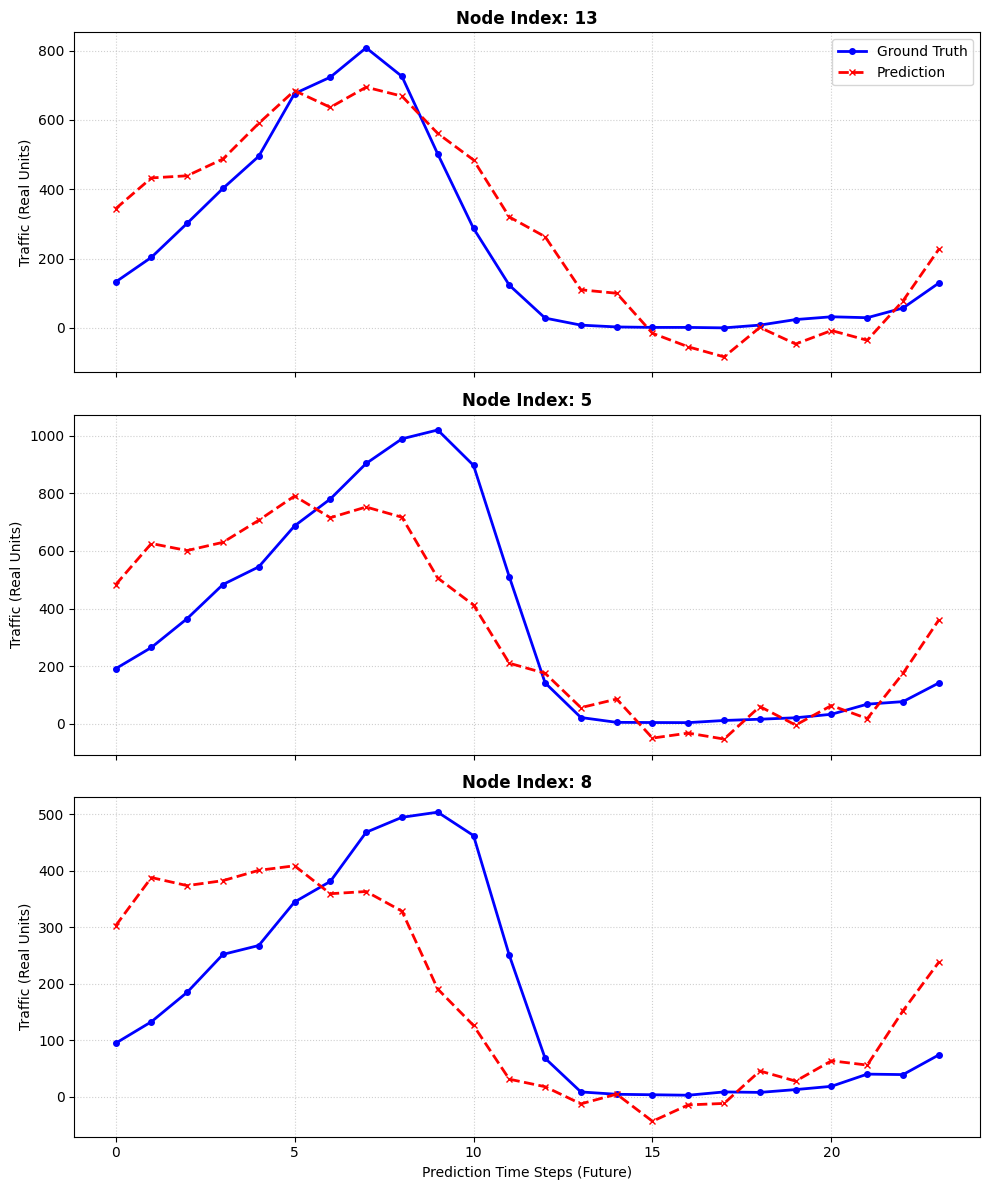

The last date is 2024-06-28 23:00:00


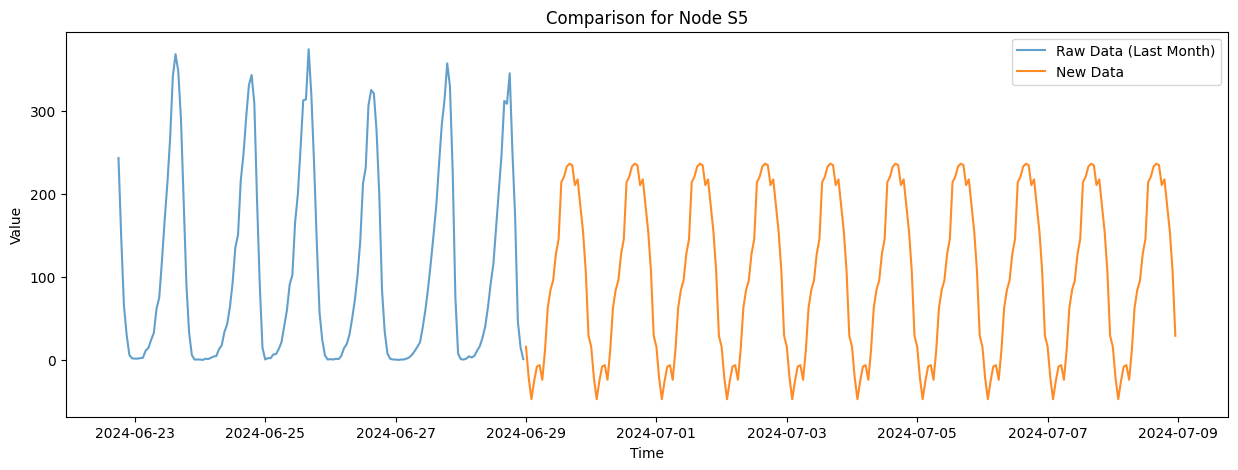

In [38]:
MODEL = iTransformer(
        num_variates=NUM_NODES,
        hist_steps=HIST_STEPS,
        pred_steps=PRED_STEPS,
        d_model=D_MODEL,   
        num_layers=LAYERS_ENC_DEC,  
        n_heads=K_HEADS,
        attn_mask=ATT_MASK_T
)

PREFIX_MODEL = 'model_itransformer_att_phy_mask'
OUTPUT_MODEL = f'{DIR_TRAINED}/{PREFIX_MODEL}_trained.pth'

print(f"Retrieving model from {OUTPUT_MODEL}")
state_dict = torch.load(OUTPUT_MODEL)
MODEL.load_state_dict(state_dict)

validate_model(MODEL, TSS_VAL_DL, SCALER, 'cpu')
validate_plots(MODEL, TSS_TRAIN_DL, SCALER, 'cpu', num_nodes_to_plot=3)
plot_prediction(MODEL, DATA_RAW_MODEL, HIST_STEPS, PRED_STEPS, 10, SCALER)
print()


# SIMULATION

### TRAINING MASKED

In [15]:
class BottomUpReconstructionLoss(nn.Module):
    def __init__(self, G_physical, device='cpu'):
        super(BottomUpReconstructionLoss, self).__init__()
        
        # Adjacency: Rows=Parents, Cols=Children
        adj = nx.to_numpy_array(G_physical)
        self.adj_matrix = torch.tensor(adj, dtype=torch.float32).to(device)
        
        # Identify Parents (Nodes with outgoing edges/children)
        row_sum = self.adj_matrix.sum(dim=1)
        self.parent_mask = (row_sum > 0).float().view(1, 1, -1).to(device)

    def forward(self, Y_pred_real, Y_true_real):
        # 1. Mix flows: Use Ground Truth for Leaves (Mask=1), Preds for Parents (Mask=0)
        # This propagates the "True" leaf traffic up to the parents
        
        F_children = Y_pred_real
        # 2. Reshape for Matrix Mult: [Batch*Time, Nodes]


        B, T, C = F_children.shape
        F_flat = F_children.reshape(B*T,C)
        
        # 3. Sum Children to find Expected Parent Flow
        # Parent_i = Sum(A_ij * Child_j) -> MatMul(F, A.T)
        F_reconstructed_flat = torch.matmul(F_flat, self.adj_matrix.t())
        F_reference = F_reconstructed_flat.reshape(B, T, C)
        
        # 4. Compare: Does Model's Parent Prediction == Sum of Children?
        # Note: We compare against Y_pred_real (what the model thinks the parent is)
        diff = Y_pred_real - F_reference
        
        # 5. Mask: Only punish Parent nodes (leaves don't have children to sum)
        loss = (diff ** 2) * self.parent_mask
        
        return loss.mean()

class CombinedTrafficLoss(nn.Module):
    def __init__(self, G_physical, scaler, device='cpu', lambda_phy=0.1, lambda_mse=1):
        """
        Args:
            G_physical: NetworkX graph (Parent -> Child edges).
            scaler: The Scaler used to scale the data.
            device: 'cuda' or 'cpu'.
            lambda_phy: Weighting factor for the physics loss (default 0.1).
        """
        super(CombinedTrafficLoss, self).__init__()
        self.lambda_phy = lambda_phy
        self.lambda_mse = lambda_mse
        self.device = device
        
        # 1. Standard Data Loss (MSE)
        self.mse = nn.MSELoss()
        
        # 2. Physics Loss (Bottom-Up Reconstruction)
        self.bottom_up = BottomUpReconstructionLoss(G_physical, device)
        
        # 3. Stats for Differentiable Reverse Transform
        # We need these to convert Z-scores to Real Flow inside the loss
       
        self.means = torch.as_tensor(scaler.mean_, device=device).float()
        self.scale = torch.as_tensor(scaler.scale_, device=device).float()


    def forward(self, Y_pred, Y_true):
        """
        Args:
            Y_pred: Model output (Normalized Z-Scores)
            Y_true: Ground Truth (Normalized Z-Scores)
        """
        B,T,C = Y_true.shape

        # --- 1. Data Loss (MSE) ---
        # Calculated on Normalized data (Standard Deep Learning practice)
        
        loss_data = self.mse(Y_pred, Y_true)
        
        # --- 2. Physics Preparation (Reverse Transform) ---
        # We must un-scale the data to check Flow Conservation.
        # Since this is just (X * std) + mean, it preserves Gradients!
        Y_pred_real = (Y_pred * self.scale) + self.means
        Y_true_real = (Y_true * self.scale) + self.means
        
        # --- 3. Physics Loss (Bottom-Up) ---
        # Calculated on Real Units
        loss_physics = self.bottom_up(Y_pred_real, Y_true_real)
        
        # --- 4. Combine ---
        total_loss = (self.lambda_mse * loss_data) + (self.lambda_phy * loss_physics)


        return total_loss, loss_data, loss_physics
    


ADJ_MATRIX_T.shape: torch.Size([16, 16])
INCIDENCE_MATRIX_T.shape: torch.Size([9, 16])
torch.Size([32, 24, 16]) torch.Size([32, 24, 16])


tensor(0, dtype=torch.int32)

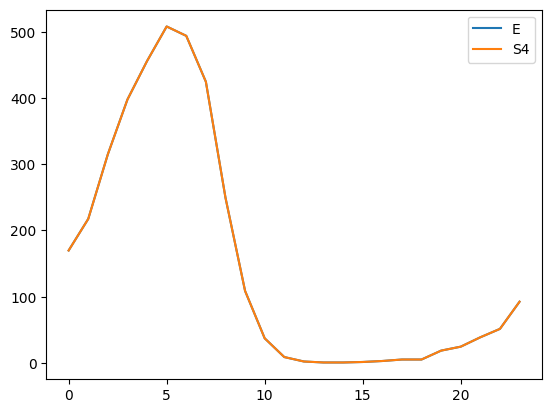

In [64]:
SCALER_MEAN_T = torch.tensor(SCALER.mean_)
SCALER_STD_T = torch.tensor(SCALER.scale_) # Note: scikit-learn uses .scale_ for standard deviation
INCIDENCE_MATRIX_T = torch.tensor(INCIDENCE_MATRIX)
ADJ_MATRIX_T = torch.tensor(ADJ_MATRIX)
print(f"ADJ_MATRIX_T.shape: {ADJ_MATRIX_T.shape}")
print(f"INCIDENCE_MATRIX_T.shape: {INCIDENCE_MATRIX_T.shape}")

parent_mask = (ADJ_MATRIX_T.sum(dim=1) > 0).float().view(1, 1, -1)

from random import randint
for batch_idx, (X, Y) in enumerate(TSS_TRAIN_DL):
    if randint(0,10) == 3:
        break

X_un = (X * SCALER_STD_T) + SCALER_MEAN_T
Y_un = (Y * SCALER_STD_T) + SCALER_MEAN_T


B,T,C = X_un.shape
print(X_un.shape, Y_un.shape)

pd.DataFrame(X_un[0,:,:].numpy(), columns=NODE_LIST)[['E','S4']].plot()

X_flows = X_un.reshape(B*T,C)
F_reconstructed_flat = torch.matmul(X_flows, ADJ_MATRIX_T.T)
F_reference = F_reconstructed_flat.reshape(B, T, C)
diff = X_un - F_reference

((diff[0][0]**2)*parent_mask).mean().int()

In [30]:
pd.DataFrame(INCIDENCE_MATRIX_T.numpy())

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,-1.0,0.0,1.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-1.0,0.0,-1.0,-1.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0
7,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,1.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0


In [172]:


class PhysicsInformedScaledLoss(nn.Module):
    def __init__(self, incidence_matrix, scaler_means, scaler_stds, lambda_kcl=0.1, base_loss_fn=nn.MSELoss()):
        """
        Args:
            incidence_matrix (torch.Tensor): N x E incidence matrix.
            scaler_means (torch.Tensor): The means from the StandardScaler (Shape: E)
            scaler_stds (torch.Tensor): The std devs from the StandardScaler (Shape: E)
            lambda_kcl (float): Weight for the KCL penalty term.
            base_loss_fn (nn.Module): The primary loss function (evaluates on scaled data).
        """
        super(PhysicsInformedScaledLoss, self).__init__()
        
        # Register matrices and scaler parameters as buffers so they sit on the correct device
        self.register_buffer('incidence_matrix', incidence_matrix.float())
        
        # Ensure means and stds are shaped correctly to broadcast over (Batch, Seq_Len, Edges)
        # Assuming they come in as 1D tensors of length E
        self.register_buffer('means', scaler_means.float().view(1, 1, -1))
        self.register_buffer('stds', scaler_stds.float().view(1, 1, -1))
        
        self.lambda_kcl = lambda_kcl
        self.base_loss_fn = base_loss_fn

    def forward(self, y_pred_scaled, y_true_scaled):
        """
        Args:
            y_pred_scaled (torch.Tensor): Shape (batch_size, seq_len, num_edges)
            y_true_scaled (torch.Tensor): Shape (batch_size, seq_len, num_edges)
        """
        # 1. Standard task loss is calculated on the SCALED values
        task_loss = self.base_loss_fn(y_pred_scaled, y_true_scaled)
        
        # 2. Unscale the predictions (This is fully differentiable!)
        # y_pred_unscaled = (y_pred_scaled * standard_deviation) + mean
        y_pred_unscaled = (y_pred_scaled * self.stds) + self.means
        
        # 3. Calculate the KCL violation on the UNSCALED physical flows
        net_node_flows = torch.matmul(y_pred_unscaled, self.incidence_matrix.T)
        
        # 4. Penalty: ideally, net_node_flows should be exactly 0
        zeros = torch.zeros_like(net_node_flows)
        kcl_penalty = nn.functional.mse_loss(net_node_flows, zeros)
        
        # 5. Combine for total loss
        total_loss = task_loss + (self.lambda_kcl * kcl_penalty)
        
        return total_loss, task_loss, kcl_penalty



In [173]:
MODEL = iTransformer(
        num_variates=NUM_NODES,
        hist_steps=HIST_STEPS,
        pred_steps=PRED_STEPS,
        d_model=D_MODEL,   
        num_layers=LAYERS_ENC_DEC,  
        n_heads=K_HEADS,
        attn_mask=None #ATT_MASK_T
).to(DEVICE)

LEAF_NODES_MASK_T = torch.tensor(LEAF_NODES_MASK.values).clone().reshape(1, 1, -1).to(DEVICE)
INCIDENCE_MATRIX_T = torch.tensor(INCIDENCE_MATRIX).clone().to(DEVICE)
SCALER_MEAN_T = torch.tensor(SCALER.mean_)
SCALER_STD_T = torch.tensor(SCALER.scale_) # Note: scikit-learn uses .scale_ for standard deviation



PATIENCE = 10

PREFIX_MODEL = 'model_itransformer_att_phy_mask_node_sim'
CHECKPOINT_PATH = f'{DIR_TRAINED}/best_{PREFIX_MODEL}.pth'
print(f"Checkpoint path: {CHECKPOINT_PATH}")

early_stopping = EarlyStopping(patience=PATIENCE, verbose=True, path=CHECKPOINT_PATH)
optimizer = torch.optim.Adam(MODEL.parameters(), lr=LR)

loss_fn = CombinedTrafficLoss(
        G_physical=G_router, 
        scaler=SCALER, 
        device=DEVICE, 
        lambda_phy=1
).to(DEVICE)

#loss_fn = PhysicsInformedScaledLoss(
#    incidence_matrix=INCIDENCE_MATRIX_T, 
#    scaler_means=SCALER_MEAN_T, 
#    scaler_stds=SCALER_STD_T, 
#    lambda_kcl=0.5
#).to(DEVICE)




Checkpoint path: TRAINED_MODELS/best_model_itransformer_att_phy_mask_node_sim.pth


### RECONTRSTRUCT GRAHPS

In [175]:
print("Starting Training...")
leaf_mask_ext = LEAF_NODES_MASK_T.clone().view(1, 1, -1).to(DEVICE)
print(f"leaf_mask_ext shape: {leaf_mask_ext.shape}")
#inner_nodes = ~LEAF_NODES_MASK_T.bool()*1

EPOCHS = 60
for epoch in range(EPOCHS):
    print(f"Epoch [{epoch+1}/{EPOCHS}]")
    # Train
    MODEL.train()
    total_loss = 0
    total_mse_loss = 0
    total_phy_loss = 0

    for batch_idx, (X, Y) in enumerate(TSS_TRAIN_DL):
        X, Y = X.to(DEVICE), Y.to(DEVICE)


        X_masked =  X.clone() 
        X_masked =  X_masked * leaf_mask_ext

        optimizer.zero_grad()
        preds = MODEL(X_masked)


        #loss, mse_val, phy_val = loss_fn(preds, X)
        loss, phy_val = loss_fn(preds, X)

        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        total_mse_loss += mse_val
        total_phy_loss += phy_val
        
    avg_train_loss = total_loss / len(TSS_TRAIN_DL)
    avg_mse_loss = total_mse_loss / len(TSS_TRAIN_DL)
    avg_phy_loss = total_phy_loss / len(TSS_TRAIN_DL)

    print(f"Epoch [{epoch+1}/{EPOCHS}] - Train Loss: {avg_train_loss:.4f}, MSE Loss: {avg_mse_loss:.4f}, Physics Loss: {avg_phy_loss:.4f}")

    # Validation
    MODEL.eval()
    val_loss = 0
    val_mse_loss = 0
    val_phy_loss = 0
    with torch.no_grad():
        for batch_idx, (X, Y) in enumerate(TSS_VAL_DL):
            X, Y = X.to(DEVICE), Y.to(DEVICE)

            X_masked = X.clone()
            X_masked = X_masked * leaf_mask_ext
            preds = MODEL(X_masked)

            #loss, mse_val, phy_val = loss_fn(preds, X)
            loss, phy_val = loss_fn(preds, X)
            
            val_loss += loss.item()
            val_mse_loss += mse_val
            val_phy_loss += phy_val
            
    avg_val_loss = val_loss / len(TSS_VAL_DL)
    avg_val_mse_loss = val_mse_loss / len(TSS_VAL_DL)
    avg_val_phy_loss = val_phy_loss / len(TSS_VAL_DL)

    print(f"Epoch [{epoch+1}/{EPOCHS}] - Validation Loss: {avg_val_loss:.4f}, MSE Loss: {avg_val_mse_loss:.4f}, Physics Loss: {avg_val_phy_loss:.4f}")
    
    # Early Stopping
    
    if early_stopping is not None:
        early_stopping(avg_val_loss, MODEL)
        if early_stopping.early_stop:
            print("Early stopping triggered. Training stopped.")
            break

# Load best model
MODEL.load_state_dict(torch.load(CHECKPOINT_PATH))
print(f"Best model weights loaded for testing: {CHECKPOINT_PATH}")

OUTPUT_MODEL = f'{DIR_TRAINED}/{PREFIX_MODEL}_trained.pth'
torch.save(MODEL.state_dict(), OUTPUT_MODEL)
print(f"Model saved to {OUTPUT_MODEL}")

Starting Training...
leaf_mask_ext shape: torch.Size([1, 1, 16])
Epoch [1/60]
Epoch [1/60] - Train Loss: 1365.3532, MSE Loss: 0.9324, Physics Loss: 1365.3529
Epoch [1/60] - Validation Loss: 13.1143, MSE Loss: 0.9324, Physics Loss: 13.1143
Validation loss decreased (inf --> 13.114254).  Saving model ...
Epoch [2/60]
Epoch [2/60] - Train Loss: 95.6374, MSE Loss: 0.9324, Physics Loss: 95.6374
Epoch [2/60] - Validation Loss: 4.3465, MSE Loss: 0.9324, Physics Loss: 4.3465
Validation loss decreased (13.114254 --> 4.346521).  Saving model ...
Epoch [3/60]
Epoch [3/60] - Train Loss: 36.2769, MSE Loss: 0.9324, Physics Loss: 36.2769
Epoch [3/60] - Validation Loss: 2.0186, MSE Loss: 0.9324, Physics Loss: 2.0186
Validation loss decreased (4.346521 --> 2.018605).  Saving model ...
Epoch [4/60]
Epoch [4/60] - Train Loss: 19.4661, MSE Loss: 0.9324, Physics Loss: 19.4661
Epoch [4/60] - Validation Loss: 0.9987, MSE Loss: 0.9324, Physics Loss: 0.9987
Validation loss decreased (2.018605 --> 0.998650).  S

### RECONTRUCT VAL TS

In [176]:
MODEL = iTransformer(
        num_variates=NUM_NODES,
        hist_steps=HIST_STEPS,
        pred_steps=PRED_STEPS,
        d_model=D_MODEL,   
        num_layers=LAYERS_ENC_DEC,  
        n_heads=K_HEADS,
        attn_mask=None
)

PREFIX_MODEL = 'model_itransformer_att_phy_mask_node_sim'
OUTPUT_MODEL = f'{DIR_TRAINED}/{PREFIX_MODEL}_trained.pth'

print(f"Retrieving model from {OUTPUT_MODEL}")
state_dict = torch.load(OUTPUT_MODEL)
MODEL.load_state_dict(state_dict)




Retrieving model from TRAINED_MODELS/model_itransformer_att_phy_mask_node_sim_trained.pth


<All keys matched successfully>

In [186]:
INNER_NODES = ['HR_A', 'MR_A', 'HR_B', 'MR_B', 'C', 'D', 'A', 'B', 'E']
OUTER_NODES = ['S1','S2','S3','S4','S5','S6','S7']

LEAF_MASK = LEAF_NODES_MASK_T.to('cpu').clone()

DATA_RAW_SIMULATION = DATA_RAW_MODEL.copy()
#DATA_RAW_SIMULATION = DATA_RAW_SIMULATION[DATA_RAW_SIMULATION.index >= (DATA_RAW_SIMULATION.index.max() - pd.DateOffset(days=10))]
DATA_RAW_SIMULATION = DATA_RAW_SIMULATION.iloc[-HIST_STEPS*10:,:]
DATA_RAW_SIMULATION.loc[:,INNER_NODES] *= .1

DATA_RAW_SIMULATION_ORIG = DATA_RAW_SIMULATION.copy()

DATA_RAW_SIMULATION

,HR_A,MR_A,HR_B,MR_B,C,D,A,B,E,S7,S6,S5,S3,S1,S2,S4
2024-06-19 00:00:00,0.366,0.366,0.901,0.901,0.366,0.350,0.535,0.384,0.078,0.16,1.01,1.70,0.34,1.47,0.04,0.78
2024-06-19 01:00:00,0.295,0.295,0.710,0.710,0.295,0.264,0.415,0.264,0.156,0.31,0.51,0.57,0.00,1.47,0.04,1.56
2024-06-19 02:00:00,0.466,0.466,1.380,1.380,0.466,0.434,0.914,0.469,0.156,0.31,0.51,2.27,0.34,4.41,0.04,1.56
2024-06-19 03:00:00,0.952,0.952,2.954,2.954,0.952,0.913,2.002,0.965,0.313,0.39,2.02,3.98,0.52,10.30,0.08,3.13
2024-06-19 04:00:00,2.098,2.098,6.755,6.755,2.098,2.011,4.657,2.149,1.095,0.87,4.05,5.11,1.38,25.01,0.08,10.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-28 19:00:00,86.122,86.122,264.590,264.590,86.122,80.922,178.469,87.887,41.679,52.00,141.74,250.69,69.65,883.82,22.00,416.79
2024-06-28 20:00:00,54.412,54.412,174.809,174.809,54.412,50.377,120.397,54.901,23.206,40.35,99.70,172.01,45.24,638.55,16.41,232.06
2024-06-28 21:00:00,22.989,22.989,75.865,75.865,22.989,20.801,52.876,22.751,11.679,21.88,44.80,46.42,19.49,291.70,9.55,116.79
2024-06-28 22:00:00,5.625,5.625,21.579,21.579,5.625,4.808,15.954,5.281,2.443,8.17,8.50,15.15,4.73,103.04,3.69,24.43


<Axes: >

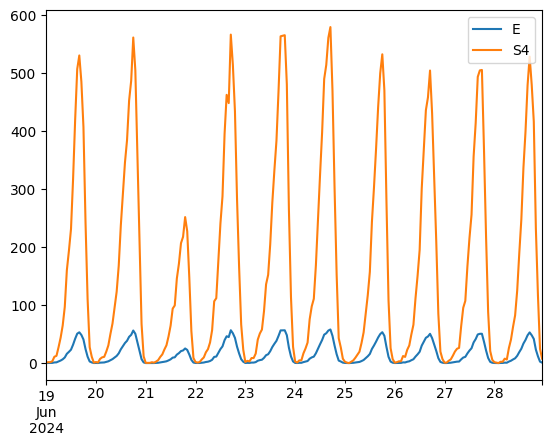

In [187]:
DATA_RAW_SIMULATION[['E','S4']].plot()

In [188]:
def reconstruct(model, dataframe, dataframe_orig, scaler_mean, scaler_std, leaf_mask):
    model.eval()

    T,C = dataframe.shape
    _raw_data = torch.tensor(dataframe.values).float().view(1,T,C)
    _raw_data_orig = torch.tensor(dataframe_orig.values).float().view(1,T,C)
    

    leaf_mask_ext = leaf_mask.view(1, 1, -1)
    scaler_mean = scaler_mean.float().view(1, 1, -1)
    scaler_std = scaler_std.float().view(1, 1, -1)

    leaf_nodes_mask_numpy = leaf_mask_ext.bool().numpy()[0][0]
    
    _dates = dataframe.index

    
    X_scaled = (_raw_data - scaler_mean) / scaler_std
    X_masked = X_scaled * leaf_mask_ext


    with torch.no_grad():
        _recon_scaled = model(X_masked)

    _recon = (_recon_scaled * scaler_std) + scaler_mean

    _recon = _recon.view(T,C)

    #_recon[:,leaf_nodes_mask_numpy] = _raw_data_orig[:,leaf_nodes_mask_numpy]


    _recon = pd.DataFrame(_recon, index=_dates, columns=dataframe.columns)


    return _recon

def reconstruct(model, dataframe, scaler_mean, scaler_std, leaf_mask):
    model.eval()

    T,C = dataframe.shape
    _raw_data = torch.tensor(dataframe.values).float().view(1,T,C)
    

    leaf_mask_ext = leaf_mask.view(1, 1, -1)
    scaler_mean = scaler_mean.float().view(1, 1, -1)
    scaler_std = scaler_std.float().view(1, 1, -1)

    leaf_nodes_mask_numpy = leaf_mask_ext.bool().numpy()[0][0]
    
    _dates = dataframe.index

    
    X_scaled = (_raw_data - scaler_mean) / scaler_std
    X_masked = X_scaled #* leaf_mask_ext


    with torch.no_grad():
        _recon_scaled = model(X_masked)

    _recon = (_recon_scaled * scaler_std) + scaler_mean

    _recon = _recon.view(T,C)

    _recon = pd.DataFrame(_recon, index=_dates, columns=dataframe.columns)


    return _recon


NUM_DAYS = DATA_RAW_SIMULATION.shape[0]/HIST_STEPS
SIM = pd.DataFrame()
for i in range(int(NUM_DAYS)):
    print(i)
    _sim = reconstruct(MODEL, DATA_RAW_SIMULATION.iloc[i*HIST_STEPS:(i+1)*HIST_STEPS,:], SCALER_MEAN_T.to('cpu'),SCALER_STD_T.to('cpu'),LEAF_NODES_MASK_T.to('cpu'))
    SIM = pd.concat([SIM, _sim], axis=0)

0
1
2
3
4
5
6
7
8
9


In [189]:
SIM

,HR_A,MR_A,HR_B,MR_B,C,D,A,B,E,S7,S6,S5,S3,S1,S2,S4
2024-06-19 00:00:00,354.089447,354.089447,1029.985840,1029.985840,354.089447,336.526825,675.890259,384.148346,177.355469,17.573135,48.647366,110.630280,47.653591,285.697601,6.272887,177.489899
2024-06-19 01:00:00,354.535736,354.535736,1031.268433,1031.268433,354.535736,336.949371,676.726135,384.633270,177.568787,17.566179,48.615013,110.563805,47.639278,285.408508,6.266244,177.333740
2024-06-19 02:00:00,354.476562,354.476562,1031.100342,1031.100342,354.476562,336.894653,676.620667,384.567871,177.549820,17.588249,48.692238,110.708626,47.691406,285.945953,6.279352,177.621521
2024-06-19 03:00:00,355.257416,355.257416,1033.346191,1033.346191,355.257416,337.638519,678.093079,385.414368,177.952637,17.609818,48.745369,110.864090,47.753128,286.216156,6.284348,177.858932
2024-06-19 04:00:00,355.728333,355.728333,1034.716797,1034.716797,355.728333,338.088440,678.998840,385.924103,178.207306,17.639555,48.832943,111.037109,47.846298,286.788910,6.297165,178.195770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-28 19:00:00,355.118896,355.118896,1032.948853,1032.948853,355.118896,337.507599,677.833618,385.264679,177.887817,17.613567,48.764404,110.876411,47.771828,286.332794,6.287551,177.943741
2024-06-28 20:00:00,354.734802,354.734802,1031.842407,1031.842407,354.734802,337.140198,677.106567,384.846985,177.683197,17.589407,48.684578,110.710915,47.691921,285.870483,6.276610,177.640518
2024-06-28 21:00:00,354.788116,354.788116,1031.994751,1031.994751,354.788116,337.191589,677.207397,384.904968,177.711945,17.606962,48.737553,110.840759,47.734882,286.216614,6.284953,177.783447
2024-06-28 22:00:00,355.359863,355.359863,1033.649048,1033.649048,355.359863,337.735596,678.293152,385.525421,178.005783,17.605349,48.712921,110.796097,47.733292,286.022064,6.280947,177.768234


<Axes: >

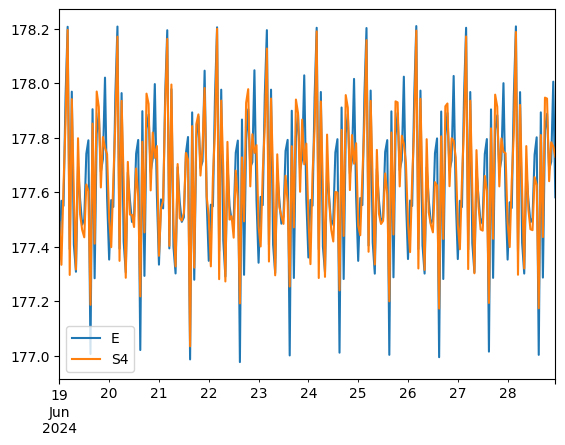

In [190]:
SIM[['E','S4']].plot()

In [ ]:


for k,v in DATA_RAW_SIMULATION.iterrows():
    print(k)

    _recons,orig = reconstruct(MODEL, DATA_RAW_SIMULATION, DATA_RAW_SIMULATION_ORIG, LEAF_MASK)
    DATA_RAW_SIMULATION.loc[k] = _recons







In [ ]:
pd.DataFrame(orig).plot()

In [214]:
Y = np.zeros((4, 5))
Y[:,[False,False,False,True,True]] = 1
Y

array([[0., 0., 0., 1., 1.],
       [0., 0., 0., 1., 1.],
       [0., 0., 0., 1., 1.],
       [0., 0., 0., 1., 1.]])

<Axes: >

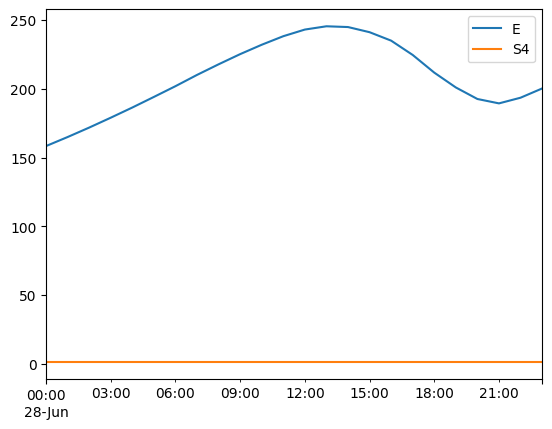

In [215]:
DATA_RAW_SIMULATION[['E','S4']].plot()